# Load Parameters

In [1]:
import json 
import os

path = "./params/folder_results_mnist_results_20260518_011639/"

files = os.listdir(path=path)

print(files)

json_file = None

with open(os.path.join(path, "model_results.json"), 'r', encoding='utf-8') as f:
    json_file = json.load(f)

['neural-9-weights.npz', 'conv2d-1-bias.npz', 'conv2d-3-weights.npz', 'conv2d-3-bias.npz', 'model_results.json', 'conv2d-5-weights.npz', 'neural-8-bias.npz', 'conv2d-1-weights.npz', 'neural-8-weights.npz', 'neural-9-bias.npz', 'conv2d-5-bias.npz']


In [2]:
layer_map = ['neural', 'conv2d', 'pool', 'flatten']

model_conf = json_file['configuration']
len(model_conf)

10

In [3]:
import numpy as np

weights_bias = {}

for i in model_conf:
    has_forward = i['forward']
    model_name = i['name']
    if has_forward:
        weights = os.path.join(path, i['wparam'])
        bias = os.path.join(path, i['bparam'])
        
        w_matrix = np.load(weights)['weights']
        b_matrix = np.load(bias)['bias']
        
        print(w_matrix.shape, b_matrix.shape, model_name)
        
        weights_bias[model_name] = {
            "w": w_matrix,
            "b": b_matrix
        }
        
    else:
        weights_bias[model_name] = None

(8, 1, 3, 3) (8,) conv2d-1
(16, 8, 3, 3) (16,) conv2d-3
(32, 16, 3, 3) (32,) conv2d-5
(32, 16) (1, 16) neural-8
(16, 10) (1, 10) neural-9


# Model

In [4]:
import numpy as np


class NeuralNetwork:
    def __init__(self, W: np.ndarray, b: np.ndarray):
        self.W = W
        self.b = b

    def forward(self, x: np.ndarray) -> np.ndarray:
        z = x @ self.W + self.b
        return np.maximum(0.0, z)


class Convolution2D:
    def __init__(
        self,
        in_channel: int,
        out_channel: int,
        k_size: int,
        stride: int,
        W: np.ndarray,
        b: np.ndarray,
    ):
        self.W = W
        self.b = b
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.k_size = k_size
        self.stride = stride

    def im2col(self, x: np.ndarray, k_size: int, stride: int = 1) -> np.ndarray:
        C, H, W = x.shape
        H_out = (H - k_size) // stride + 1
        W_out = (W - k_size) // stride + 1

        shape = (C, H_out, W_out, k_size, k_size)
        strides = (
            x.strides[0],
            x.strides[1] * stride,
            x.strides[2] * stride,
            x.strides[1],
            x.strides[2],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        col = patches.transpose(0, 3, 4, 1, 2).reshape(C * k_size * k_size, -1)
        return col

    def forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W_img = x.shape

        if C != self.in_channel:
            raise ValueError(
                f"Channel input {C} tidak sesuai dengan in_channel={self.in_channel}."
            )
        if H < self.k_size or W_img < self.k_size:
            raise ValueError(
                f"Kernel size {self.k_size} lebih besar dari "
                f"spatial input ({H}x{W_img})."
            )

        H_out = (H - self.k_size) // self.stride + 1
        W_out = (W_img - self.k_size) // self.stride + 1

        col   = self.im2col(x, self.k_size, self.stride)
        W_col = self.W.reshape(self.out_channel, -1)

        z = W_col @ col
        z += self.b[:, np.newaxis]
        z = z.reshape(self.out_channel, H_out, W_out)

        return np.maximum(0.0, z)


class MaxPooling:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        if x.ndim != 3:
            raise ValueError(
                f"Input harus 3-D (C, H, W), dapat {x.shape}."
            )
        return self._local_forward(x)

    def _local_forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W = x.shape
        k, s = 2, 2

        if H < k or W < k:
            raise ValueError(
                f"Kernel ({k}x{k}) lebih besar dari spatial input ({H}x{W})."
            )

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        shape = (C, H_out, W_out, k, k)
        strides = (
            x.strides[0],
            x.strides[1] * s,
            x.strides[2] * s,
            x.strides[1],
            x.strides[2],
        )
        windows = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        out = windows.reshape(C, H_out, W_out, k * k).max(axis=-1)
        return out


class FlattenLayer:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        return x.flatten()


class SoftmaxLayer:
    def __init__(self):
        pass

    def forward(self, z: np.ndarray) -> np.ndarray:
        z_shifted = z - np.max(z)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z)

# Model Load and Defenitions

In [5]:
conv1_weights = weights_bias['conv2d-1']['w']
conv1_bias = weights_bias['conv2d-1']['b']
conv1 = Convolution2D(1, 8, 3, 1, conv1_weights, conv1_bias)

conv2_weights = weights_bias['conv2d-3']['w']
conv2_bias = weights_bias['conv2d-3']['b']
conv2 = Convolution2D(8, 16, 3, 1, conv2_weights, conv2_bias)

conv3_weights = weights_bias['conv2d-5']['w']
conv3_bias = weights_bias['conv2d-5']['b']
conv3 = Convolution2D(16, 32, 3, 1, conv3_weights, conv3_bias)

In [6]:
neural1_weights = weights_bias["neural-8"]["w"]
neural1_bias = weights_bias["neural-8"]["b"]
neural1 = NeuralNetwork(neural1_weights, neural1_bias)

neural2_weights = weights_bias["neural-9"]["w"]
neural2_bias = weights_bias["neural-9"]["b"]
neural2 = NeuralNetwork(neural2_weights, neural2_bias)

In [7]:
pool = MaxPooling()

In [8]:
flatten = FlattenLayer()

In [9]:
softmax = SoftmaxLayer()

# Data

In [10]:
import pandas as pd

data_file_path = "../data/MNIST_CSV/mnist_train.csv"

df = pd.read_csv(data_file_path)

df.head(5)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
Y = df.iloc[0:, 0:1]
x = df.iloc[0:, 1:] / 255

x = x.to_numpy()
Y = Y.to_numpy()
print(x.shape, Y.shape)

(59999, 784) (59999, 1)


In [12]:
x = x.reshape(59999, 1, 28, 28)

nb_classes = 10
one_hot_targets = np.eye(nb_classes)[Y]
one_hot_targets = one_hot_targets.reshape(one_hot_targets.shape[0], -1)

In [13]:
x.shape, one_hot_targets.shape

((59999, 1, 28, 28), (59999, 10))

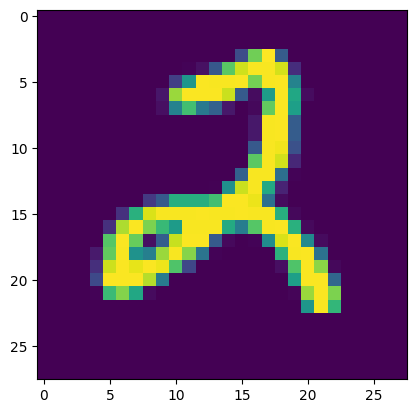

In [14]:
from matplotlib import pyplot as plt

random_choice = np.random.randint(0, 5999)
plt.imshow(x[random_choice][0])
plt.show()

# Model Sanitize Check

In [40]:
random_choice = np.random.randint(0, 5999)
x_sample = x[random_choice]
x_sample = x_sample.reshape(1, 28, 28)

res = conv1.forward(x_sample)
print(res.shape)

res = pool.forward(res)
print(res.shape)

res = conv2.forward(res)
print(res.shape)

res = pool.forward(res)
print(res.shape)

res = conv3.forward(res)
print(res.shape)

res = pool.forward(res)
print(res.shape)

res = flatten.forward(res)
print(res.shape)

res = neural1.forward(res)
print(res.shape)

res = neural2.forward(res)
print(res.shape)

res = softmax.forward(res)
print(res.shape)

print(np.argmax(res))
print(res)
print(one_hot_targets[random_choice])

(8, 26, 26)
(8, 13, 13)
(16, 11, 11)
(16, 5, 5)
(32, 3, 3)
(32, 1, 1)
(32,)
(1, 16)
(1, 10)
(1, 10)
1
[[1.82167377e-04 9.98360494e-01 1.82167377e-04 1.82167377e-04
  1.82167377e-04 1.82167377e-04 1.82167377e-04 1.82167377e-04
  1.82167377e-04 1.82167377e-04]]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


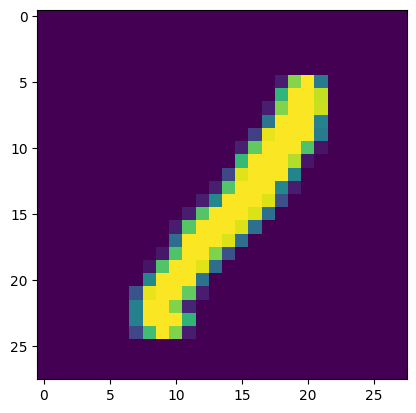

In [41]:
plt.imshow(x_sample[0])
plt.show()

In [38]:
x[0]
one_hot_targets[0]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

# Check

In [ ]:
def block2(x):
    x_sample = x[0]
    x_sample = x_sample.reshape(1, 28, 28)

    res = conv1.forward(x_sample)
    res = pool.forward(res)
    res = conv2.forward(res)
    res = pool.forward(res)
    print(res.shape)
    
    return res